# Mejora del modelo — SARIMA vs SARIMAX por producto

Notebook que busca construir series semanales por **producto real unificado**. Se corrige el problema de productos duplicados como `Mango`, `Mango St` y `Mango Staff`, agrupándolos bajo un solo producto base (`Mango`) y conservando variables indicadoras para `Staff` y `St` como posibles variables externas en SARIMAX.

In [1]:
# =============================================================================
# 0. LIBRERÍAS Y CONFIGURACIÓN
# =============================================================================

import os
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.simplefilter("ignore", ConvergenceWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.rcParams["figure.figsize"] = (12, 5)

RANDOM_STATE = 42
HORIZONTE = 4          # 4 semanas adelante
M = 4                  # patrón estacional mensual aproximado en datos semanales

In [2]:
# =============================================================================
# 1. CARGA DE DATOS
# =============================================================================

# El notebook intenta encontrar el archivo en diferentes nombres comunes.
posibles_archivos = [
    "ice_cream_data_daily.csv",
    "ice_cream_data_daily(1).csv",
    "/mnt/data/ice_cream_data_daily.csv",
    "/mnt/data/ice_cream_data_daily(1).csv"
]

ruta_csv = None
for ruta in posibles_archivos:
    if os.path.exists(ruta):
        ruta_csv = ruta
        break

if ruta_csv is None:
    raise FileNotFoundError("No se encontró ice_cream_data_daily.csv. Pon el archivo en la misma carpeta del notebook.")

print("Archivo cargado:", ruta_csv)

df = pd.read_csv(ruta_csv)
df.head()

Archivo cargado: ice_cream_data_daily.csv


,Product,Date_clean,Revenue
0,1 Topping,2017-04-01,0.0
1,1 Topping,2017-04-02,0.0
2,1 Topping,2017-04-03,0.0
3,1 Topping,2017-04-04,0.0
4,1 Topping,2017-04-05,0.0


## 2. Limpieza de datos y unificación de productos

se conservan banderas como `is_staff` e `is_student_price` para que SARIMAX pueda usar esa información como variable externa.

In [3]:
# =============================================================================
# 2. LIMPIEZA INICIAL
# =============================================================================

# Validación mínima de columnas
columnas_requeridas = {"Product", "Date_clean", "Revenue"}
faltantes = columnas_requeridas - set(df.columns)
if faltantes:
    raise ValueError(f"Faltan columnas requeridas en el CSV: {faltantes}")

# Tipos de datos
df["Date_clean"] = pd.to_datetime(df["Date_clean"], errors="coerce")
df["Revenue"] = pd.to_numeric(df["Revenue"], errors="coerce")

# Eliminar filas sin información esencial
df = df.dropna(subset=["Date_clean", "Product", "Revenue"]).copy()

# Limpieza básica de nombres
df["Product_clean"] = (
    df["Product"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Correcciones antes de eliminar sufijos St/Staff
correcciones_iniciales = {
    "Hezelnut": "Hazelnut",
    "Hezelnut St": "Hazelnut St",
    "Pure Coco .": "Pure Coco",
    "Pure Coco . St": "Pure Coco St",
    "Pure Coconut": "Pure Coco",
    "Pure Coconut Staff": "Pure Coco Staff",
    "IceCream Sand": "Ice Cream Sand",
    "IceCream Sand St": "Ice Cream Sand St",
    "Cus IC Sand": "Ice Cream Sand",
    "Cus. IC Sand": "Ice Cream Sand",
    "S Caramel": "S. Caramel",
    "S Caramel St": "S. Caramel St",
    "Salted Caramel": "S. Caramel"
}

df["Product_clean"] = df["Product_clean"].replace(correcciones_iniciales)

# Flags importantes ANTES de unificar producto
df["is_staff"] = df["Product_clean"].str.contains(r"Staff", case=False, na=False).astype(int)
df["is_student_price"] = df["Product_clean"].str.contains(r"St$", case=False, na=False).astype(int)

# Producto base: eliminar SOLO sufijos al final, no letras internas como "St" en Strawberry
# Ejemplo: "Mango Staff" -> "Mango"; "Mango St" -> "Mango"; "Strawberry" queda igual.
df["Product_final"] = (
    df["Product_clean"]
    .str.replace(r"\s+Staff$", "", case=False, regex=True)
    .str.replace(r"\s+St$", "", case=False, regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

# Correcciones finales después de quitar sufijos
correcciones_finales = {
    "S Caramel": "S. Caramel",
    "Salted Caramel": "S. Caramel",
    "Pure Coco .": "Pure Coco",
    "Pure Coconut": "Pure Coco",
    "IceCream Sand": "Ice Cream Sand",
    "YY Seasame": "YY Sesame",
    "Cherry Almond Fudge": "Cherry Almond Fudge"
}

df["Product_final"] = df["Product_final"].replace(correcciones_finales)

print("Filas:", len(df))
print("Productos originales:", df["Product_clean"].nunique())
print("Productos finales unificados:", df["Product_final"].nunique())

df[["Product", "Product_clean", "Product_final", "is_staff", "is_student_price"]].drop_duplicates().sort_values("Product_final").head(40)

Filas: 19032
Productos originales: 104
Productos finales unificados: 58


,Product,Product_clean,Product_final,is_staff,is_student_price
0,1 Topping,1 Topping,1 Topping,0,0
183,1 Topping Staff,1 Topping Staff,1 Topping,0,0
366,1 Toppings St,1 Toppings St,1 Toppings,0,0
549,3 Topping,3 Topping,3 Topping,0,0
732,3 Topping Staff,3 Topping Staff,3 Topping,0,0
915,Apricot,Apricot,Apricot,0,0
1098,Apricot ST,Apricot ST,Apricot,0,0
1281,Apricot Staff,Apricot Staff,Apricot,0,0
1464,Asia Research Free Scoop,Asia Research Free Scoop,Asia Research Free Scoop,0,0
2013,Banana Staff,Banana Staff,Banana,0,0


In [4]:
# =============================================================================
# 3. IDENTIFICAR PROMOCIONES / DESCUENTOS / AJUSTES
# =============================================================================

# IMPORTANTE: "Staff" NO se elimina como promoción; se unifica al producto base.
# Solo se marcan ajustes/promociones explícitas, vouchers, redenciones y descuentos.
patrones_promo = [
    "Promotion",
    "Voucher",
    "REDEEM",
    "Staff Off",
    "Registration",
    "Discount",
    "Double Scoop",
    "Triple Scoop"
]

patron_regex = "|".join(patrones_promo)

df["is_promo"] = df["Product_clean"].str.contains(patron_regex, case=False, na=False).astype(int)
df["is_negative"] = (df["Revenue"] < 0).astype(int)
df["is_adjustment"] = ((df["is_promo"] == 1) | (df["is_negative"] == 1)).astype(int)

print("Filas totales:", len(df))
print("Promociones / ajustes:", int(df["is_adjustment"].sum()))
print("Ventas Staff:", int(df["is_staff"].sum()))
print("Ventas St:", int(df["is_student_price"].sum()))

Filas totales: 19032
Promociones / ajustes: 2408
Ventas Staff: 0
Ventas St: 0


In [5]:
# =============================================================================
# 4. BASE LIMPIA PARA MODELAR DEMANDA REAL POR PRODUCTO
# =============================================================================

# Se eliminan ajustes/promociones como productos, pero NO se eliminan Staff/St.
# Staff/St ya fueron agrupados al producto base y quedan como información externa.
data = df[(df["is_adjustment"] == 0) & (df["Revenue"] > 0)].copy()

print("Filas después de limpieza:", len(data))
print("Productos finales en data:", data["Product_final"].nunique())

data[["Product_clean", "Product_final", "Revenue", "is_staff", "is_student_price"]].head()

Filas después de limpieza: 4212
Productos finales en data: 37


,Product_clean,Product_final,Revenue,is_staff,is_student_price
40,1 Topping,1 Topping,5.0,0,0
66,1 Topping,1 Topping,5.0,0,0
101,1 Topping,1 Topping,5.0,0,0
104,1 Topping,1 Topping,5.0,0,0
106,1 Topping,1 Topping,5.0,0,0


In [6]:
# =============================================================================
# 5. SELECCIÓN DE PRODUCTOS RELEVANTES POR PARETO 80%
# =============================================================================

revenue_producto = (
    data.groupby("Product_final", as_index=False)["Revenue"]
    .sum()
    .sort_values("Revenue", ascending=False)
    .reset_index(drop=True)
)

revenue_producto["pct"] = revenue_producto["Revenue"] / revenue_producto["Revenue"].sum()
revenue_producto["pct_acum"] = revenue_producto["pct"].cumsum()

top_productos = revenue_producto.loc[revenue_producto["pct_acum"] <= 0.80, "Product_final"].tolist()

# Asegurar mínimo 5 productos para comparación
if len(top_productos) < 5:
    top_productos = revenue_producto.head(5)["Product_final"].tolist()

print("Productos seleccionados:")
for p in top_productos:
    print("-", p)

revenue_producto.head(20)

Productos seleccionados:
- S. Caramel
- Mango
- Chocolate
- Mint Choco
- Pure Coco
- Strawberry
- Chai Tea
- Waffle Cone
- Green Tea
- Hazelnut
- Pina Colada
- Banana Caramel


,Product_final,Revenue,pct,pct_acum
0,S. Caramel,38988.00549,0.131774,0.131774
1,Mango,26469.23377,0.089462,0.221236
2,Chocolate,24769.45739,0.083717,0.304954
3,Mint Choco,22963.92639,0.077615,0.382569
4,Pure Coco,22539.42423,0.076180,0.458749
5,Strawberry,20728.25757,0.070059,0.528808
6,Chai Tea,15459.42423,0.052251,0.581058
7,Waffle Cone,15113.03185,0.051080,0.632138
8,Green Tea,14924.09090,0.050441,0.682580
9,Hazelnut,11864.66666,0.040101,0.722681


In [7]:
# =============================================================================
# 6. CONSTRUIR SERIES SEMANALES POR PRODUCTO
# =============================================================================

data_top = data[data["Product_final"].isin(top_productos)].copy()
data_top["Week"] = data_top["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)

revenue_por_producto = (
    data_top.groupby(["Product_final", "Week"], as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Product_final": "producto", "Week": "ds", "Revenue": "y"})
    .sort_values(["producto", "ds"])
)

fechas_semanales = pd.date_range(
    start=revenue_por_producto["ds"].min(),
    end=revenue_por_producto["ds"].max(),
    freq="W-MON"
)

series_completas = []
for producto in top_productos:
    temp = revenue_por_producto[revenue_por_producto["producto"] == producto].copy()
    temp = (
        temp.set_index("ds")
        .reindex(fechas_semanales)
        .rename_axis("ds")
        .reset_index()
    )
    temp["producto"] = producto
    temp["y"] = temp["y"].fillna(0)
    series_completas.append(temp)

revenue_por_producto = pd.concat(series_completas, ignore_index=True)

resumen_series = (
    revenue_por_producto.groupby("producto")
    .agg(
        semanas=("ds", "count"),
        avg_hkd=("y", "mean"),
        std_hkd=("y", "std"),
        total_hkd=("y", "sum")
    )
    .reset_index()
)
resumen_series["cv"] = resumen_series["std_hkd"] / resumen_series["avg_hkd"]

resumen_series.sort_values("total_hkd", ascending=False)

,producto,semanas,avg_hkd,std_hkd,total_hkd,cv
9,S. Caramel,27,1444.000203,700.319637,38988.00549,0.484986
5,Mango,27,980.341991,521.393071,26469.23377,0.531848
2,Chocolate,27,917.387311,415.304989,24769.45739,0.452704
6,Mint Choco,27,850.515792,525.866977,22963.92639,0.618292
8,Pure Coco,27,834.793490,550.483523,22539.42423,0.659425
10,Strawberry,27,767.713243,389.759735,20728.25757,0.507689
1,Chai Tea,27,572.571268,369.012827,15459.42423,0.644484
11,Waffle Cone,27,559.741920,167.804851,15113.03185,0.299790
3,Green Tea,27,552.744107,407.840854,14924.09090,0.737847
4,Hazelnut,27,439.432099,386.741260,11864.66666,0.880093


## 7. Variables exógenas para SARIMAX

Se usan variables externas con interpretación de negocio:

- `promo_count`: número de filas promocionales o ajustes por semana.
- `promo_value`: valor absoluto de ingresos negativos por semana.
- `staff_count`: cantidad de registros tipo Staff del producto en la semana.
- `staff_revenue`: revenue asociado a Staff del producto en la semana.
- `student_count`: cantidad de registros tipo St del producto en la semana.
- `total_transactions`: número total de transacciones por semana.

Estas variables se escalan dentro de cada producto usando solo el train para evitar fuga de información.

In [8]:
# =============================================================================
# 7. VARIABLES EXÓGENAS PARA SARIMAX
# =============================================================================

# Semana en la base completa
df["Week"] = df["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)
data["Week"] = data["Date_clean"].dt.to_period("W").apply(lambda r: r.start_time)

# Variables globales por semana: promociones, ajustes y volumen total de operación
exog_global = (
    df.groupby("Week")
    .agg(
        promo_count=("is_adjustment", "sum"),
        promo_value=("Revenue", lambda x: np.abs(x[x < 0]).sum()),
        total_transactions=("Revenue", "count")
    )
    .reset_index()
    .rename(columns={"Week": "ds"})
)

exog_global["promo_flag"] = (exog_global["promo_count"] > 0).astype(int)

# Variables específicas por producto: Staff/St, ya usando producto unificado
exog_producto = (
    data_top.groupby(["Product_final", "Week"])
    .agg(
        staff_count=("is_staff", "sum"),
        staff_revenue=("Revenue", lambda x: x[data_top.loc[x.index, "is_staff"] == 1].sum()),
        student_count=("is_student_price", "sum")
    )
    .reset_index()
    .rename(columns={"Product_final": "producto", "Week": "ds"})
)

# Unir target + exógenas
dataset_modelos = (
    revenue_por_producto
    .merge(exog_global, on="ds", how="left")
    .merge(exog_producto, on=["producto", "ds"], how="left")
)

dataset_modelos = dataset_modelos.fillna(0)

columnas_exogenas = [
    "promo_count",
    "promo_value",
    "promo_flag",
    "total_transactions",
    "staff_count",
    "staff_revenue",
    "student_count"
]

print("Columnas exógenas usadas:", columnas_exogenas)
dataset_modelos.head()

Columnas exógenas usadas: ['promo_count', 'promo_value', 'promo_flag', 'total_transactions', 'staff_count', 'staff_revenue', 'student_count']


,ds,producto,y,promo_count,promo_value,total_transactions,promo_flag,staff_count,staff_revenue,student_count
0,2017-03-27,S. Caramel,430.00000,26,91.0,208,1,0.0,0.0,0.0
1,2017-04-03,S. Caramel,2978.00000,91,1237.0,728,1,0.0,0.0,0.0
2,2017-04-10,S. Caramel,2465.48387,93,1257.0,728,1,0.0,0.0,0.0
3,2017-04-17,S. Caramel,653.47619,95,763.0,728,1,0.0,0.0,0.0
4,2017-04-24,S. Caramel,1694.00000,96,583.0,728,1,0.0,0.0,0.0


In [9]:
# =============================================================================
# 8. FUNCIONES AUXILIARES
# =============================================================================

def calcular_metricas(y_real, y_pred):
    y_real = np.array(y_real, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    mae = np.mean(np.abs(y_real - y_pred))
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))

    mask = y_real != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_real[mask] - y_pred[mask]) / y_real[mask])) * 100
    else:
        mape = np.nan

    return mae, rmse, mape


def escalar_exog(train_exog, test_exog):
    """Escala variables exógenas usando solo media/desviación del train."""
    train_exog = train_exog.astype(float).copy()
    test_exog = test_exog.astype(float).copy()

    mu = train_exog.mean()
    sigma = train_exog.std().replace(0, 1)

    train_scaled = (train_exog - mu) / sigma
    test_scaled = (test_exog - mu) / sigma

    return train_scaled, test_scaled


def predicciones_validas(pred, y_train):
    """Filtro defensivo para evitar modelos explotados numéricamente."""
    pred = np.array(pred, dtype=float)
    if np.any(~np.isfinite(pred)):
        return False
    if np.any(pred < 0):
        return False

    max_train = max(float(np.max(y_train)), 1.0)
    # No se acepta un forecast irrealmente mayor a 5 veces el máximo histórico del producto.
    if np.any(pred > 5 * max_train):
        return False

    return True

In [10]:
# =============================================================================
# 9. GRID SEARCH SARIMA ESTABLE
# =============================================================================

def entrenar_sarima_grid(y_train_log, m=4):
    mejores = {
        "aic": np.inf,
        "order": None,
        "seasonal_order": None,
        "model": None
    }

    # Grid reducido para evitar inestabilidad con solo ~27 semanas
    p = q = range(0, 2)
    d = range(0, 2)
    P = Q = range(0, 2)
    D = range(0, 1)

    for order in product(p, d, q):
        for seasonal in product(P, D, Q):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], m)

            try:
                model = SARIMAX(
                    y_train_log,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False, maxiter=300)

                converged = fitted.mle_retvals.get("converged", True)
                if not converged:
                    continue

                if np.isfinite(fitted.aic) and fitted.aic < mejores["aic"]:
                    mejores.update({
                        "aic": fitted.aic,
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "model": fitted
                    })
            except Exception:
                continue

    return mejores

In [11]:
# =============================================================================
# 10. GRID SEARCH SARIMAX ESTABLE
# =============================================================================

def entrenar_sarimax_grid(y_train_log, exog_train, m=4):
    mejores = {
        "aic": np.inf,
        "order": None,
        "seasonal_order": None,
        "model": None
    }

    # Grid reducido para evitar sobreajuste e inestabilidad
    p = q = range(0, 2)
    d = range(0, 2)
    P = Q = range(0, 2)
    D = range(0, 1)

    for order in product(p, d, q):
        for seasonal in product(P, D, Q):
            seasonal_order = (seasonal[0], seasonal[1], seasonal[2], m)

            try:
                model = SARIMAX(
                    y_train_log,
                    exog=exog_train,
                    order=order,
                    seasonal_order=seasonal_order,
                    trend="n",
                    enforce_stationarity=False,
                    enforce_invertibility=False
                )
                fitted = model.fit(disp=False, maxiter=300)

                converged = fitted.mle_retvals.get("converged", True)
                if not converged:
                    continue

                if np.isfinite(fitted.aic) and fitted.aic < mejores["aic"]:
                    mejores.update({
                        "aic": fitted.aic,
                        "order": order,
                        "seasonal_order": seasonal_order,
                        "model": fitted
                    })
            except Exception:
                continue

    return mejores

In [13]:
# =============================================================================
# 11. ENTRENAMIENTO SARIMA vs SARIMAX POR PRODUCTO
# =============================================================================

resultados = []
predicciones = {}

for producto in top_productos:
    print("" + "=" * 70)
    print(f"Producto: {producto}")
    print("=" * 70)

    serie = (
        dataset_modelos[dataset_modelos["producto"] == producto]
        .sort_values("ds")
        .reset_index(drop=True)
    )

    if len(serie) <= HORIZONTE + 8:
        print("Serie muy corta. Se omite.")
        continue

    train = serie.iloc[:-HORIZONTE].copy()
    test = serie.iloc[-HORIZONTE:].copy()

    y_train = train["y"].values.astype(float)
    y_test = test["y"].values.astype(float)

    # Si el producto casi no tiene venta en train, se omite
    if y_train.sum() == 0:
        print("Producto sin revenue en train. Se omite.")
        continue

    y_train_log = np.log1p(y_train)

    # ==========================
    # SARIMA
    # ==========================
    mejor_sarima = entrenar_sarima_grid(y_train_log, m=M)

    if mejor_sarima["model"] is not None:
        forecast_log = mejor_sarima["model"].forecast(steps=HORIZONTE)
        pred_sarima = np.expm1(forecast_log)
        pred_sarima = np.maximum(pred_sarima, 0)

        if not predicciones_validas(pred_sarima, y_train):
            pred_sarima = np.array([np.nan] * HORIZONTE)
            mae_sarima = rmse_sarima = mape_sarima = np.nan
        else:
            mae_sarima, rmse_sarima, mape_sarima = calcular_metricas(y_test, pred_sarima)
    else:
        pred_sarima = np.array([np.nan] * HORIZONTE)
        mae_sarima = rmse_sarima = mape_sarima = np.nan

    # ==========================
    # SARIMAX
    # ==========================
    exog_train = train[columnas_exogenas]
    exog_test = test[columnas_exogenas]
    exog_train_scaled, exog_test_scaled = escalar_exog(exog_train, exog_test)

    mejor_sarimax = entrenar_sarimax_grid(y_train_log, exog_train_scaled, m=M)

    if mejor_sarimax["model"] is not None:
        forecast_log_x = mejor_sarimax["model"].forecast(
            steps=HORIZONTE,
            exog=exog_test_scaled
        )
        pred_sarimax = np.expm1(forecast_log_x)
        pred_sarimax = np.maximum(pred_sarimax, 0)

        if not predicciones_validas(pred_sarimax, y_train):
            pred_sarimax = np.array([np.nan] * HORIZONTE)
            mae_sarimax = rmse_sarimax = mape_sarimax = np.nan
        else:
            mae_sarimax, rmse_sarimax, mape_sarimax = calcular_metricas(y_test, pred_sarimax)
    else:
        pred_sarimax = np.array([np.nan] * HORIZONTE)
        mae_sarimax = rmse_sarimax = mape_sarimax = np.nan

    # ==========================
    # Elegir mejor modelo por MAPE, con fallback si alguno es NaN
    # ==========================
    if np.isfinite(mape_sarima) and np.isfinite(mape_sarimax):
        mejor_modelo = "SARIMA" if mape_sarima <= mape_sarimax else "SARIMAX"
        mejor_mape = min(mape_sarima, mape_sarimax)
    elif np.isfinite(mape_sarima):
        mejor_modelo = "SARIMA"
        mejor_mape = mape_sarima
    elif np.isfinite(mape_sarimax):
        mejor_modelo = "SARIMAX"
        mejor_mape = mape_sarimax
    else:
        mejor_modelo = "Sin modelo estable"
        mejor_mape = np.nan

    resultados.append({
        "Producto": producto,
        "SARIMA_order": mejor_sarima["order"],
        "SARIMA_seasonal": mejor_sarima["seasonal_order"],
        "SARIMA_MAE": mae_sarima,
        "SARIMA_RMSE": rmse_sarima,
        "SARIMA_MAPE": mape_sarima,
        "SARIMAX_order": mejor_sarimax["order"],
        "SARIMAX_seasonal": mejor_sarimax["seasonal_order"],
        "SARIMAX_MAE": mae_sarimax,
        "SARIMAX_RMSE": rmse_sarimax,
        "SARIMAX_MAPE": mape_sarimax,
        "Mejor_modelo": mejor_modelo,
        "Mejor_MAPE": mejor_mape
    })

    predicciones[producto] = {
        "train": train,
        "test": test,
        "pred_sarima": pred_sarima,
        "pred_sarimax": pred_sarimax
    }

    print(f"SARIMA  -> MAE: {mae_sarima:.0f} | RMSE: {rmse_sarima:.0f} | MAPE: {mape_sarima:.1f}%")
    print(f"SARIMAX -> MAE: {mae_sarimax:.0f} | RMSE: {rmse_sarimax:.0f} | MAPE: {mape_sarimax:.1f}%")
    print(f"Mejor modelo: {mejor_modelo}")

df_resultados = pd.DataFrame(resultados)
df_resultados

Producto: S. Caramel
SARIMA  -> MAE: 1099 | RMSE: 1240 | MAPE: 60.8%
SARIMAX -> MAE: 909 | RMSE: 1265 | MAPE: 47.1%
Mejor modelo: SARIMAX
Producto: Mango
SARIMA  -> MAE: 580 | RMSE: 740 | MAPE: 239.1%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Chocolate
SARIMA  -> MAE: 671 | RMSE: 729 | MAPE: 60.8%
SARIMAX -> MAE: 628 | RMSE: 638 | MAPE: 62.4%
Mejor modelo: SARIMA
Producto: Mint Choco
SARIMA  -> MAE: 260 | RMSE: 315 | MAPE: 34.0%
SARIMAX -> MAE: 552 | RMSE: 764 | MAPE: 62.4%
Mejor modelo: SARIMA
Producto: Pure Coco
SARIMA  -> MAE: 235 | RMSE: 301 | MAPE: 96.3%
SARIMAX -> MAE: 650 | RMSE: 690 | MAPE: 190.9%
Mejor modelo: SARIMA
Producto: Strawberry
SARIMA  -> MAE: 169 | RMSE: 232 | MAPE: 18.1%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Chai Tea
SARIMA  -> MAE: 329 | RMSE: 436 | MAPE: 38.2%
SARIMAX -> MAE: nan | RMSE: nan | MAPE: nan%
Mejor modelo: SARIMA
Producto: Waffle Cone
SARIMA  -> MAE: 103 | RMSE: 117 | MAPE: 21.1%


,Producto,SARIMA_order,SARIMA_seasonal,SARIMA_MAE,SARIMA_RMSE,SARIMA_MAPE,SARIMAX_order,SARIMAX_seasonal,SARIMAX_MAE,SARIMAX_RMSE,SARIMAX_MAPE,Mejor_modelo,Mejor_MAPE
0,S. Caramel,"(0, 1, 1)","(0, 0, 1, 4)",1098.551244,1239.800452,60.801608,"(1, 0, 0)","(1, 0, 0, 4)",909.374895,1264.928131,47.096843,SARIMAX,47.096843
1,Mango,"(0, 1, 1)","(0, 0, 1, 4)",580.114396,740.253385,239.140722,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,239.140722
2,Chocolate,"(0, 0, 1)","(1, 0, 1, 4)",670.702228,729.279494,60.760150,"(0, 0, 0)","(0, 0, 1, 4)",627.533729,637.796118,62.433734,SARIMA,60.760150
3,Mint Choco,"(0, 1, 1)","(0, 0, 1, 4)",260.130862,315.138621,33.962156,"(0, 0, 0)","(0, 0, 1, 4)",552.071861,764.231241,62.448586,SARIMA,33.962156
4,Pure Coco,"(0, 1, 1)","(1, 0, 1, 4)",235.185160,301.450044,96.303291,"(1, 0, 1)","(1, 0, 1, 4)",650.156442,690.037629,190.946983,SARIMA,96.303291
5,Strawberry,"(1, 1, 1)","(0, 0, 1, 4)",169.236102,231.949091,18.083948,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,18.083948
6,Chai Tea,"(0, 1, 1)","(1, 0, 1, 4)",328.618235,436.246210,38.159232,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,38.159232
7,Waffle Cone,"(0, 1, 1)","(1, 0, 0, 4)",102.830181,117.497391,21.067253,"(1, 0, 0)","(1, 0, 0, 4)",249.031359,305.776052,50.570197,SARIMA,21.067253
8,Green Tea,"(0, 1, 1)","(0, 0, 1, 4)",656.428572,754.521445,57.044516,"(0, 1, 1)","(0, 0, 1, 4)",NaN,NaN,NaN,SARIMA,57.044516
9,Hazelnut,"(1, 1, 1)","(1, 0, 1, 4)",629.069552,803.524840,63.028985,"(0, 1, 1)","(1, 0, 1, 4)",NaN,NaN,NaN,SARIMA,63.028985


In [ ]:
# =============================================================================
# 12. TABLA FINAL COMPARATIVA
# =============================================================================

df_comparacion = df_resultados[[
    "Producto",
    "SARIMA_MAE", "SARIMA_RMSE", "SARIMA_MAPE",
    "SARIMAX_MAE", "SARIMAX_RMSE", "SARIMAX_MAPE",
    "Mejor_modelo", "Mejor_MAPE"
]].sort_values("Mejor_MAPE")

df_comparacion

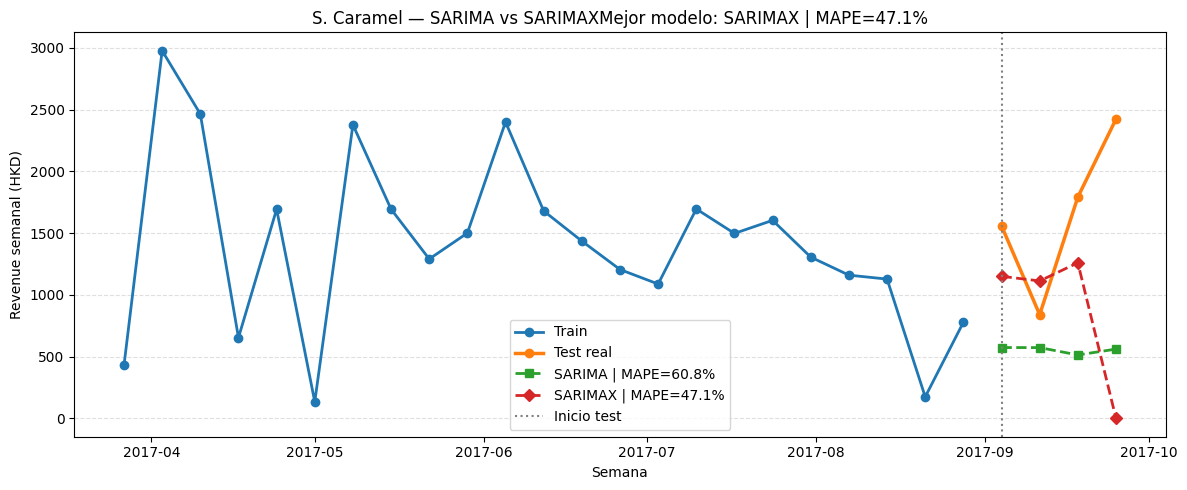

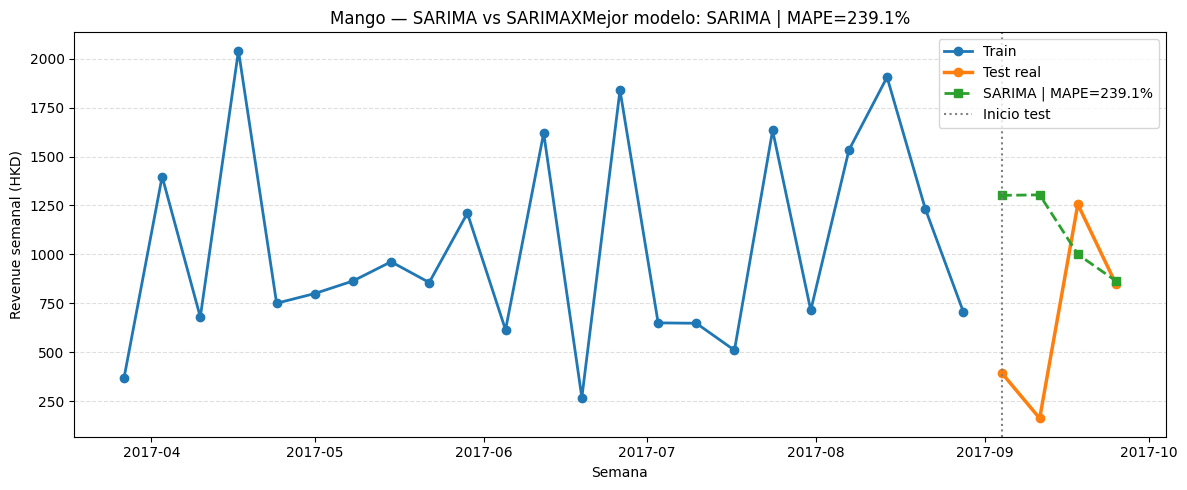

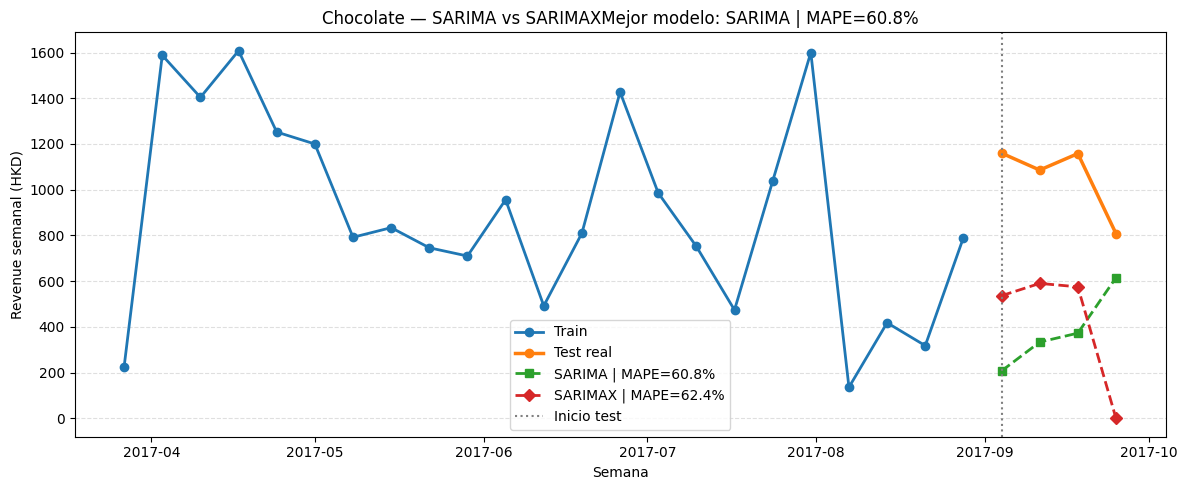

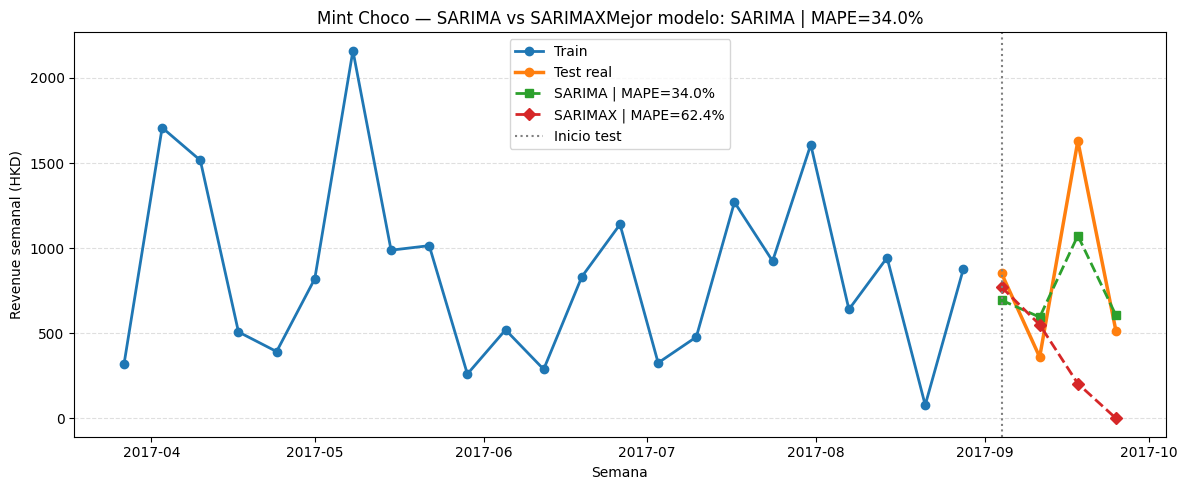

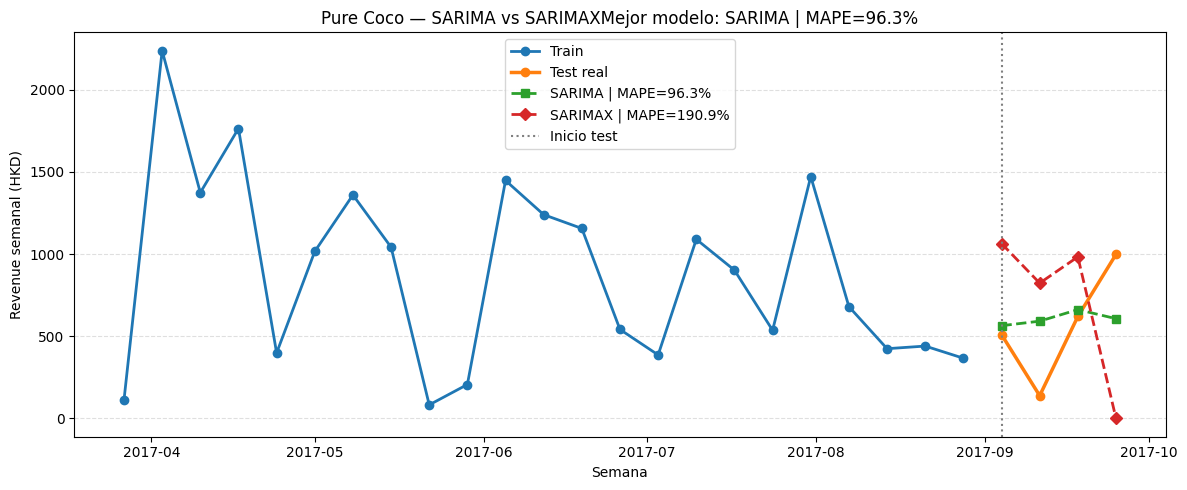

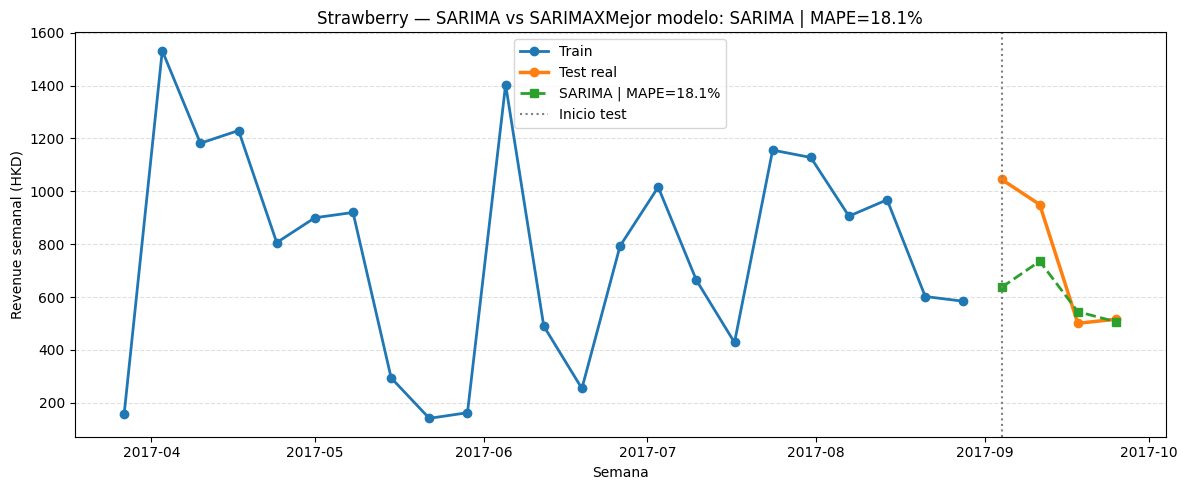

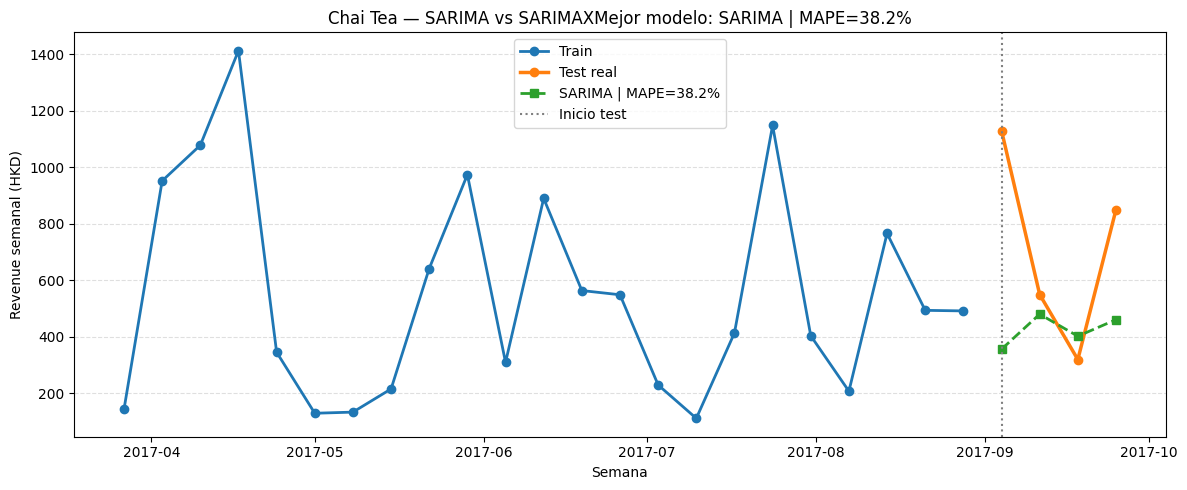

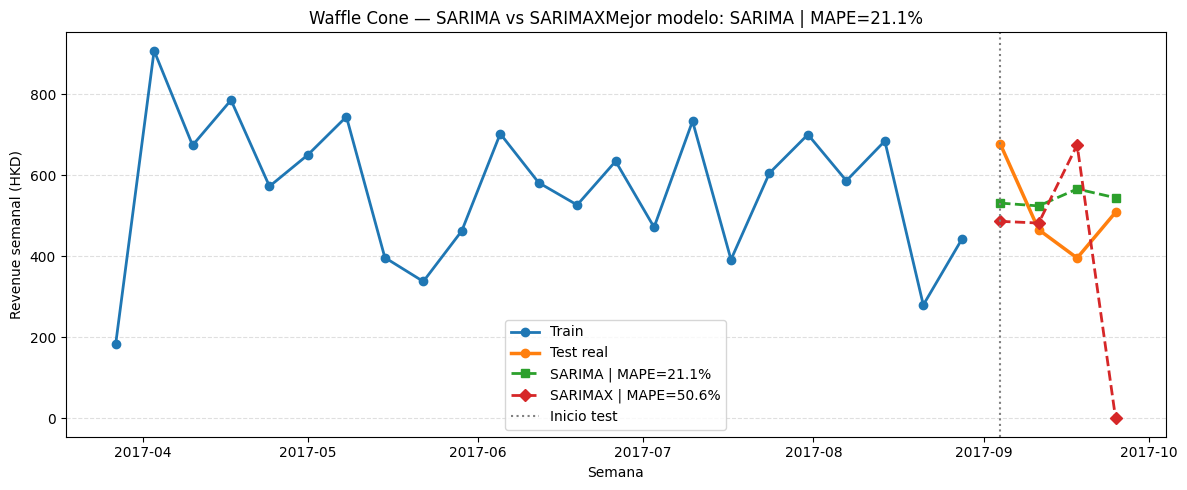

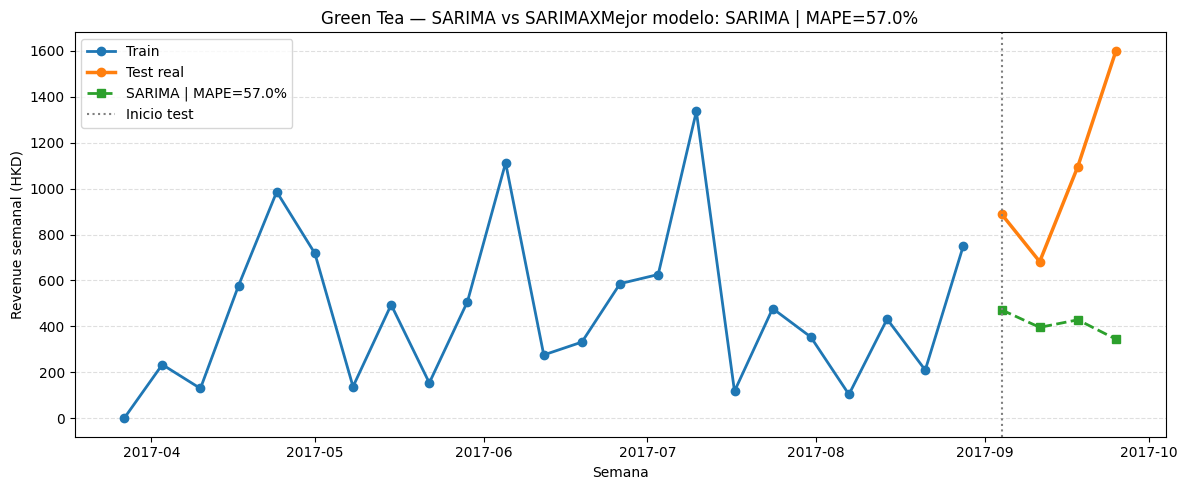

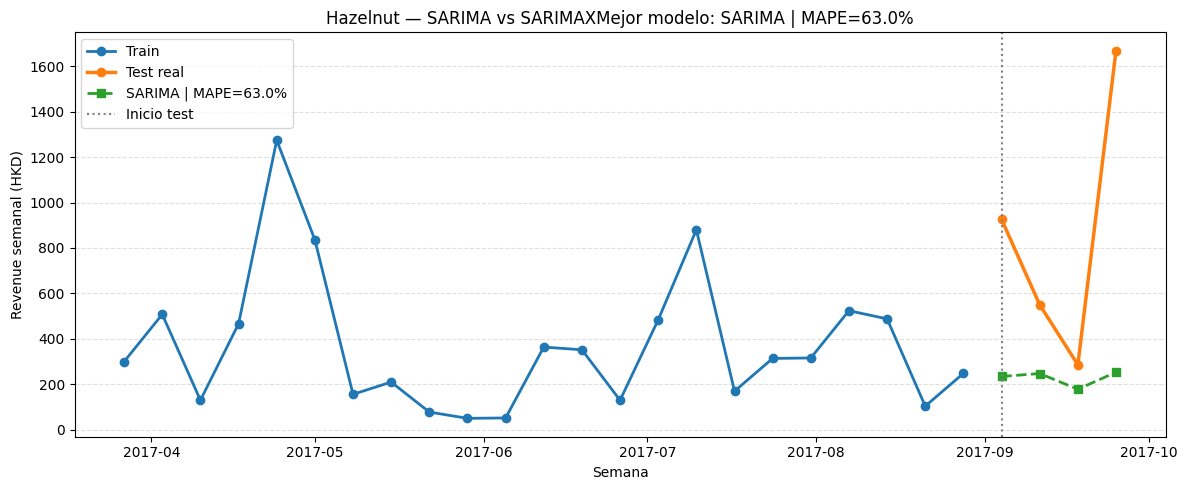

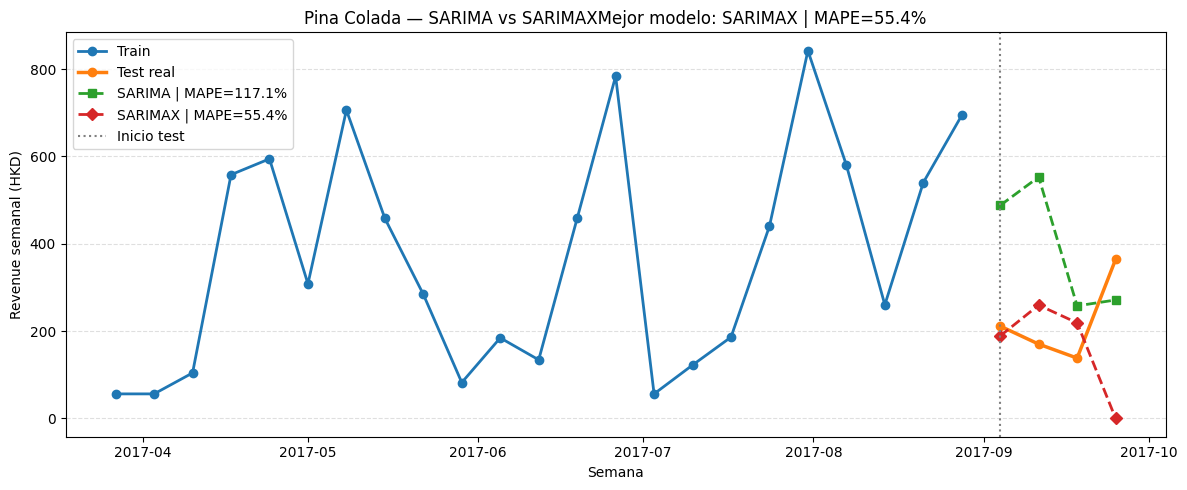

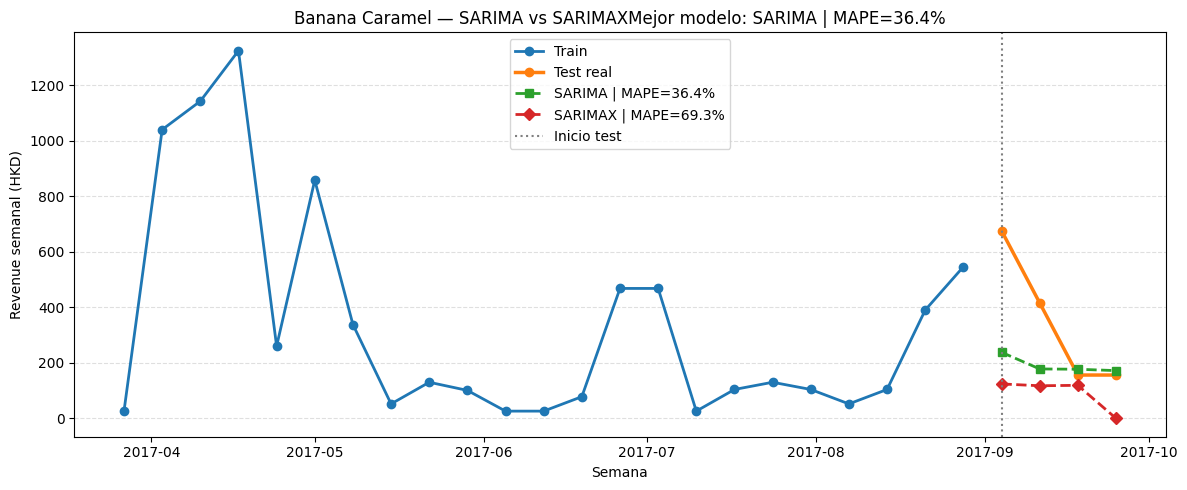

In [16]:
# =============================================================================
# 13. GRÁFICAS SARIMA vs SARIMAX POR PRODUCTO
# =============================================================================

for producto, d in predicciones.items():
    train = d["train"]
    test = d["test"]
    pred_sarima = d["pred_sarima"]
    pred_sarimax = d["pred_sarimax"]

    fila = df_resultados[df_resultados["Producto"] == producto].iloc[0]

    plt.figure(figsize=(12, 5))
    plt.plot(train["ds"], train["y"], marker="o", linewidth=2, label="Train")
    plt.plot(test["ds"], test["y"], marker="o", linewidth=2.5, label="Test real")

    if np.all(np.isfinite(pred_sarima)):
        plt.plot(test["ds"], pred_sarima, marker="s", linestyle="--", linewidth=2,
                 label=f"SARIMA | MAPE={fila['SARIMA_MAPE']:.1f}%")

    if np.all(np.isfinite(pred_sarimax)):
        plt.plot(test["ds"], pred_sarimax, marker="D", linestyle="--", linewidth=2,
                 label=f"SARIMAX | MAPE={fila['SARIMAX_MAPE']:.1f}%")

    plt.axvline(test["ds"].iloc[0], linestyle=":", color="gray", label="Inicio test")
    plt.title(
        f"{producto} — SARIMA vs SARIMAX"
        f"Mejor modelo: {fila['Mejor_modelo']} | MAPE={fila['Mejor_MAPE']:.1f}%"
    )
    plt.xlabel("Semana")
    plt.ylabel("Revenue semanal (HKD)")
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()